# CNN with PyTorch — From Zero to Hero 🇩🇿
Comprehensive, hands-on notebook with **exercises** and **corrections**, covering:
- Building a CNN from scratch
- Pooling types (max/avg/global)
- Data augmentation
- Training & evaluation loops
- Checkpointing & loading
- **Fine-tuning** a pretrained model (ResNet18)

> This mirrors the TensorFlow version, implemented in **PyTorch**.


## 0) Environment & Install (optional)
Uncomment if you need to install packages.

In [1]:

# %%bash
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install matplotlib numpy scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
     -------- ------------------------------- 0.5/2.4 MB 1.9 MB/s eta 0:00:02
     ------------ --------------------------- 0.8/2.4 MB 2.1 MB/s eta 0:00:01
     ----------------- ---------------------- 1.0/2.4 MB 1.9 MB/s eta 0:00:01
     ------------------------- -------------- 1.6/2.4 MB 1.8 MB/s eta 0:00:01
     ------------------------- -------------- 1.6/2.4 MB 1.8 MB/s eta 0:00:01
     ------------------------------ --------- 1.8/2.4 MB 1.5 MB/s eta 0:00:01
     ---------------------------------- ----- 2.1/2.4 MB 1.5 MB/s eta 0:00:01
     -------------------------

## 1) Imports & Config

In [2]:

import os, math, time, random
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from itertools import product

SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## 2) Dataset & Dataloaders
Choose **MNIST** (1x28x28) or **CIFAR10** (3x32x32).

In [3]:

DATASET = "CIFAR10"  # or "MNIST"
DATA_DIR = "./data"
BATCH_SIZE = 128

if DATASET == "MNIST":
    num_classes = 10
    input_channels = 1
    transform_train = transforms.Compose([
        transforms.ToTensor(),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_ds = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform_train)
    test_ds  = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform_test)
elif DATASET == "CIFAR10":
    num_classes = 10
    input_channels = 3
    transform_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_ds = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=transform_train)
    test_ds  = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=transform_test)
else:
    raise ValueError("Unsupported DATASET")

len(train_ds), len(test_ds), num_classes, input_channels


100%|██████████| 170M/170M [01:35<00:00, 1.79MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


(50000, 10000, 10, 3)

### 2.1) Visualize Samples

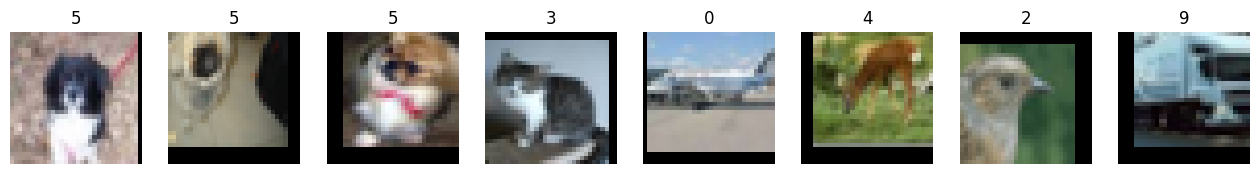

In [4]:

def show_batch(ds, n=8):
    import numpy as np
    idxs = np.random.choice(len(ds), size=n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for ax, idx in zip(axes, idxs):
        x, y = ds[idx]
        ax.imshow(np.transpose(x.numpy(), (1, 2, 0)) if x.shape[0] == 3 else x.squeeze().numpy())
        ax.set_title(str(y))
        ax.axis('off')
    plt.show()

show_batch(train_ds, n=8)


## 3) Simple CNN Model
A compact CNN with Conv → ReLU → Pool blocks.

In [5]:

class SmallCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, pool_type='max'):
        super().__init__()
        if pool_type == 'max':
            Pool = nn.MaxPool2d
        elif pool_type == 'avg':
            Pool = nn.AvgPool2d
        else:
            raise ValueError("pool_type must be 'max' or 'avg'")

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            Pool(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            Pool(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (8 if in_channels==3 else 7) * (8 if in_channels==3 else 7), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SmallCNN(in_channels=input_channels, num_classes=num_classes, pool_type='max').to(device)
sum(p.numel() for p in model.parameters())/1e6, model


(0.591274,
 SmallCNN(
   (features): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): ReLU()
     (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (3): ReLU()
     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (6): ReLU()
     (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (8): ReLU()
     (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=4096, out_features=128, bias=True)
     (2): ReLU()
     (3): Dropout(p=0.3, inplace=False)
     (4): Linear(in_features=128, out_features=10, bias=True)
   )
 ))

## 4) Training & Evaluation Utilities

In [6]:

def accuracy(pred, target):
    return (pred.argmax(1) == target).float().mean().item()

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        running_acc  += (out.argmax(1) == y).float().sum().item()
    return running_loss/len(loader.dataset), running_acc/len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    all_y = []
    all_pred = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        running_loss += loss.item() * x.size(0)
        running_acc  += (out.argmax(1) == y).float().sum().item()
        all_y.append(y.cpu().numpy())
        all_pred.append(out.argmax(1).cpu().numpy())
    import numpy as np
    all_y = np.concatenate(all_y)
    all_pred = np.concatenate(all_pred)
    return running_loss/len(loader.dataset), running_acc/len(loader.dataset), all_y, all_pred


## 5) Train Baseline

In [7]:

VAL_SPLIT = 0.1
val_len = int(len(train_ds)*VAL_SPLIT)
train_len = len(train_ds) - val_len
train_subset, val_subset = random_split(train_ds, [train_len, val_len], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,    batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5
train_hist, val_hist = [], []
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
    train_hist.append((tr_loss, tr_acc)); val_hist.append((va_loss, va_acc))
    print(f"Epoch {epoch:02d} | train: loss={tr_loss:.4f}, acc={tr_acc:.4f} | val: loss={va_loss:.4f}, acc={va_acc:.4f}")


Epoch 01 | train: loss=1.8724, acc=0.3023 | val: loss=1.5966, acc=0.4058
Epoch 02 | train: loss=1.5467, acc=0.4328 | val: loss=1.4402, acc=0.4772
Epoch 03 | train: loss=1.4079, acc=0.4859 | val: loss=1.2891, acc=0.5290
Epoch 04 | train: loss=1.3096, acc=0.5282 | val: loss=1.1915, acc=0.5762
Epoch 05 | train: loss=1.2296, acc=0.5564 | val: loss=1.1528, acc=0.5824


### 5.1) Plot Learning Curves

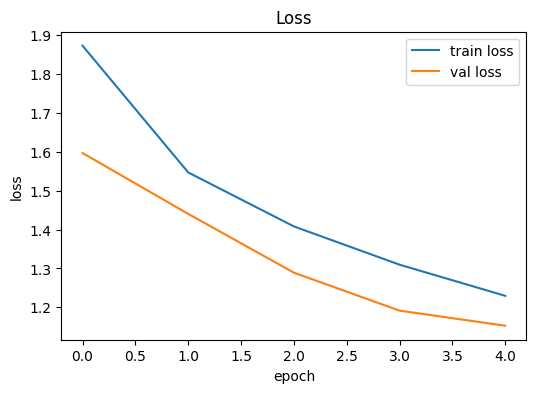

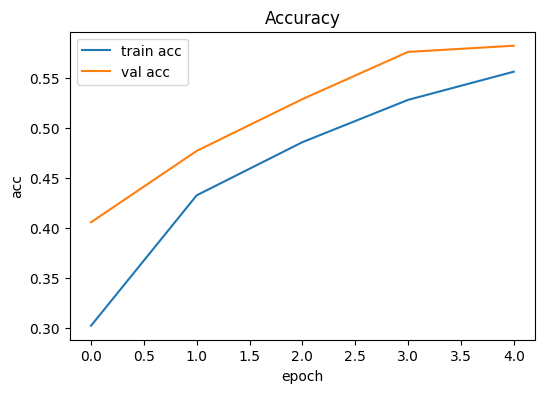

In [8]:

tl = [x[0] for x in train_hist]; ta = [x[1] for x in train_hist]
vl = [x[0] for x in val_hist];   va = [x[1] for x in val_hist]

plt.figure(figsize=(6,4))
plt.plot(tl, label='train loss')
plt.plot(vl, label='val loss')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Loss'); plt.show()

plt.figure(figsize=(6,4))
plt.plot(ta, label='train acc')
plt.plot(va, label='val acc')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('acc'); plt.title('Accuracy'); plt.show()


### 5.2) Evaluate on Test Set

Test: loss=1.0430, acc=0.6217

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.58      0.66      1000
           1       0.77      0.73      0.75      1000
           2       0.49      0.42      0.45      1000
           3       0.49      0.35      0.41      1000
           4       0.52      0.58      0.55      1000
           5       0.57      0.47      0.51      1000
           6       0.54      0.85      0.66      1000
           7       0.67      0.70      0.68      1000
           8       0.79      0.75      0.77      1000
           9       0.65      0.79      0.72      1000

    accuracy                           0.62     10000
   macro avg       0.63      0.62      0.62     10000
weighted avg       0.63      0.62      0.62     10000



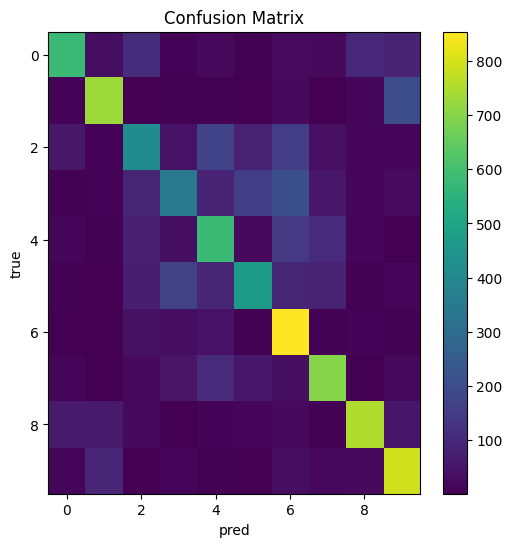

In [9]:

test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
print(f"Test: loss={test_loss:.4f}, acc={test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, aspect='auto')
plt.title('Confusion Matrix'); plt.xlabel('pred'); plt.ylabel('true')
plt.colorbar(); plt.show()


## 6) Pooling Types: Max vs Avg vs GlobalAvg
Try different pooling strategies.

In [10]:

def make_model(pool_type='max'):
    return SmallCNN(in_channels=input_channels, num_classes=num_classes, pool_type=pool_type).to(device)

for p in ['max', 'avg']:
    m = make_model(p)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    tr_loss, tr_acc = train_epoch(m, train_loader, criterion, opt)
    va_loss, va_acc, _, _ = evaluate(m, val_loader, criterion)
    print(f"{p.upper()} pooling -> train acc: {tr_acc:.3f} | val acc: {va_acc:.3f}")


MAX pooling -> train acc: 0.319 | val acc: 0.437
AVG pooling -> train acc: 0.302 | val acc: 0.397


## 7) Save & Load Checkpoints

In [11]:

CKPT = "cnn_checkpoint.pt"
torch.save({'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'meta': {'dataset': DATASET}}, CKPT)
print("Saved:", CKPT)

ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(ckpt['model_state'])
print("Loaded meta:", ckpt['meta'])


Saved: cnn_checkpoint.pt
Loaded meta: {'dataset': 'CIFAR10'}


C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_15564\3918422280.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT, map_location=device)


## 8) Fine-Tuning a Pretrained Model (ResNet18)

In [ ]:

from torchvision.models import resnet18, ResNet18_Weights

ft_transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
ft_transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
])

ft_train = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=ft_transform_train)
ft_test  = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=ft_transform_test)

val_len = int(len(ft_train)*0.1)
train_len = len(ft_train) - val_len
ft_train_ds, ft_val_ds = random_split(ft_train, [train_len, val_len], generator=torch.Generator().manual_seed(SEED))

ft_train_loader = DataLoader(ft_train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
ft_val_loader   = DataLoader(ft_val_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
for p in resnet.parameters():
    p.requires_grad = False
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

opt = optim.Adam(resnet.fc.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

EPOCHS = 3
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(resnet, ft_train_loader, crit, opt)
    va_loss, va_acc, _, _ = evaluate(resnet, ft_val_loader, crit)
    print(f"[Frozen] Epoch {ep}: train acc={tr_acc:.3f} | val acc={va_acc:.3f}")

for name, p in resnet.named_parameters():
    if "layer4" in name or "layer3" in name:
        p.requires_grad = True

opt = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-4)
EPOCHS = 2
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(resnet, ft_train_loader, crit, opt)
    va_loss, va_acc, _, _ = evaluate(resnet, ft_val_loader, crit)
    print(f"[Unfrozen] Epoch {ep}: train acc={tr_acc:.3f} | val acc={va_acc:.3f}")


---
# 🧪 Exercises

### Exercise 1 — Build Your Own CNN (TODO)

In [ ]:

class MyCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

m = MyCNN(in_channels=input_channels, num_classes=num_classes).to(device)
opt = optim.Adam(m.parameters(), lr=1e-3)
tr_loss, tr_acc = train_epoch(m, train_loader, criterion, opt)
va_loss, va_acc, _, _ = evaluate(m, val_loader, criterion)
print(f"Exercise1 baseline -> val acc: {va_acc:.3f}")


### Exercise 2 — Try Different Pooling

In [ ]:

class GAPCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

m2 = GAPCNN(in_channels=input_channels, num_classes=num_classes).to(device)
opt = optim.Adam(m2.parameters(), lr=1e-3)
tr_loss, tr_acc = train_epoch(m2, train_loader, criterion, opt)
va_loss, va_acc, _, _ = evaluate(m2, val_loader, criterion)
print(f"GAP val acc: {va_acc:.3f}")


### Exercise 3 — Data Augmentation

In [ ]:

aug_train = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
]))
aug_loader = DataLoader(aug_train, batch_size=128, shuffle=True, num_workers=2)
m3 = SmallCNN(in_channels=input_channels, num_classes=num_classes, pool_type='max').to(device)
opt = optim.Adam(m3.parameters(), lr=1e-3)
tr_loss, tr_acc = train_epoch(m3, aug_loader, criterion, opt)
print(f"One epoch with aug -> train acc: {tr_acc:.3f}")


### Exercise 4 — Fine-Tune Different Layers

In [ ]:

from torchvision.models import resnet18, ResNet18_Weights
res = resnet18(weights=ResNet18_Weights.DEFAULT).to(device)
for p in res.parameters(): p.requires_grad = False
res.fc = nn.Linear(res.fc.in_features, 10).to(device)

def finetune_layers(unfreeze_layers=("layer4",)):
    for n, p in res.named_parameters():
        p.requires_grad = any(layer in n for layer in unfreeze_layers) or ("fc" in n)
    opt = optim.Adam(filter(lambda p: p.requires_grad, res.parameters()), lr=1e-4)
    tr_loss, tr_acc = train_epoch(res, ft_train_loader, criterion, opt)
    va_loss, va_acc, _, _ = evaluate(res, ft_val_loader, criterion)
    return va_acc

for layers in [("layer4",), ("layer3","layer4"), ("layer2","layer3","layer4")]:
    va = finetune_layers(layers)
    print("Unfrozen:", layers, "-> val acc:", round(va,3))


---
# ✅ Corrections / Reference Solutions

In [ ]:

class RefCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
                nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
                nn.MaxPool2d(2)
            )
        self.features = nn.Sequential(
            block(in_channels, 64),
            block(64, 128),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

ref = RefCNN(in_channels=input_channels, num_classes=num_classes).to(device)
opt = optim.Adam(ref.parameters(), lr=1e-3)
tr_loss, tr_acc = train_epoch(ref, train_loader, criterion, opt)
va_loss, va_acc, _, _ = evaluate(ref, val_loader, criterion)
print("Reference CNN val acc:", round(va_acc,3))


_Generated on 2025-10-01T15:39:53.237590Z_